# California Housing Price Prediction
### An End-to-End Machine Learning Regression Project

**Goal:** Predict the median house value of a California census block group (1990 census data) using features like location, income, and housing characteristics.

**Pipeline:** Explore → Clean → Model → Evaluate → Explain

This notebook follows the standard end-to-end regression workflow: EDA, preprocessing, feature engineering, training multiple models, evaluating with regression metrics, and a small interactive prediction demo.

## 1. Setup & First Look

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)
np.random.seed(42)

In [2]:
df = pd.read_csv("housing.csv")
print("Shape:", df.shape)
df.info()

Shape: (20640, 10)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(4), int64(5), str(1)
memory usage: 1.6 MB


In [3]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [5]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100,INLAND
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100,INLAND
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300,INLAND
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700,INLAND
20639,-121.24,39.37,16,2785,616.0,1387,530,2.3886,89400,INLAND


**What do we notice?**

- The dataset has 20,640 rows and 10 columns, matching the census block-group description — one row per neighborhood.
- `total_bedrooms` has missing values (207 of them), which we'll need to handle before modeling.
- `median_house_value` (our target) is capped around \$500,001 — it looks like values were clipped at the top, which we should keep in mind since it can distort a model trained to predict beyond that cap.
- `median_income` is scaled oddly (values like 3.87 rather than a dollar figure) — it's actually in tens of thousands of USD, per the data dictionary, so a value of 3.87 means about \$38,700.
- `ocean_proximity` is the only categorical column and will need encoding before it can be fed into a model.
- Questions this raises: How strongly does location (lat/long) relate to price? Does the capped target value distort model performance for expensive homes? Is `total_bedrooms` missing at random or concentrated somewhere specific?

## 2. Exploratory Data Analysis (EDA)

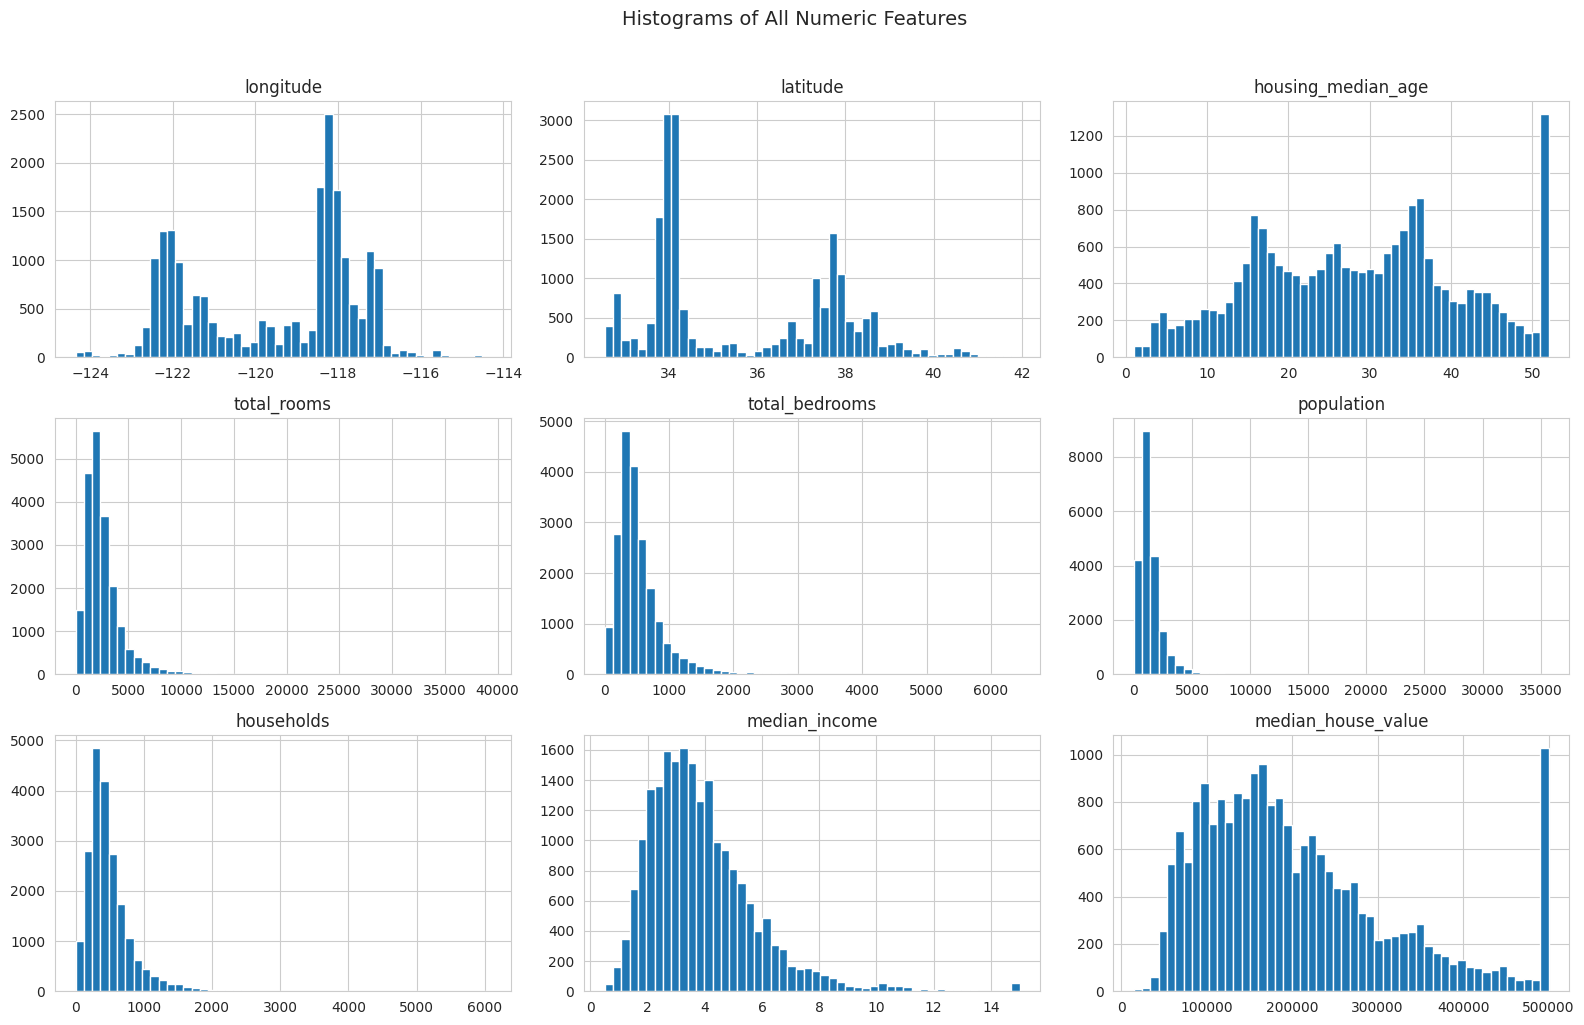

In [6]:
df.hist(bins=50, figsize=(16, 10))
plt.suptitle("Histograms of All Numeric Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

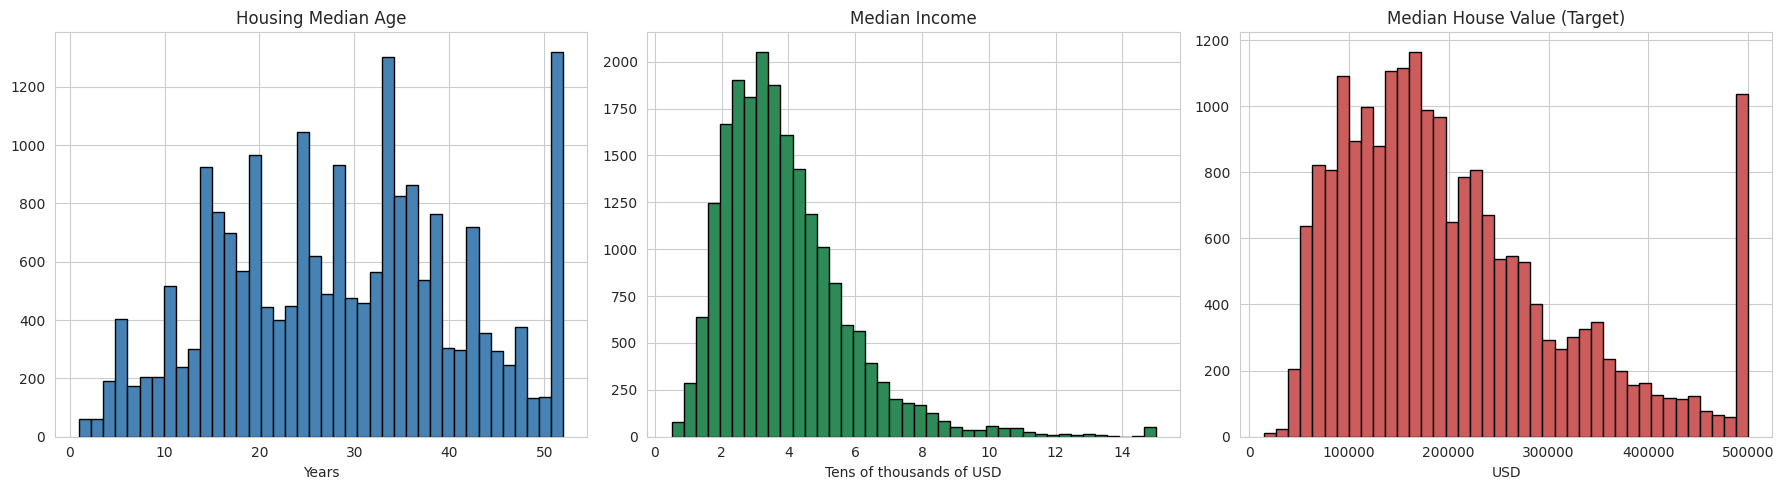

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df["housing_median_age"], bins=40, color="steelblue", edgecolor="black")
axes[0].set_title("Housing Median Age")
axes[0].set_xlabel("Years")

axes[1].hist(df["median_income"], bins=40, color="seagreen", edgecolor="black")
axes[1].set_title("Median Income")
axes[1].set_xlabel("Tens of thousands of USD")

axes[2].hist(df["median_house_value"], bins=40, color="indianred", edgecolor="black")
axes[2].set_title("Median House Value (Target)")
axes[2].set_xlabel("USD")

plt.tight_layout()
plt.show()

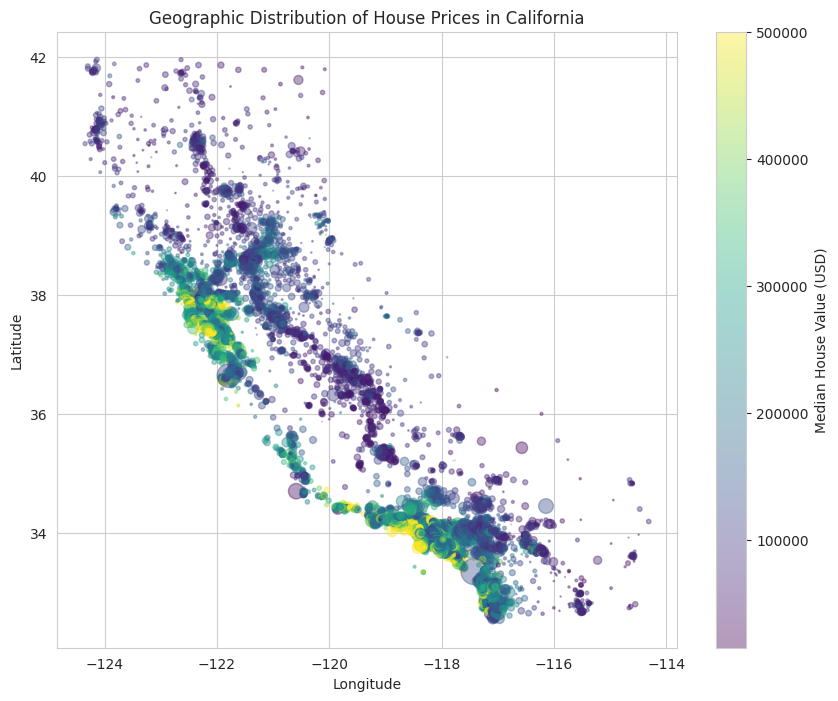

In [8]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    df["longitude"], df["latitude"],
    c=df["median_house_value"], cmap="viridis",
    alpha=0.4, s=df["population"] / 100, label="population (size)"
)
plt.colorbar(scatter, label="Median House Value (USD)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of House Prices in California")
plt.show()

This scatter plot roughly traces the shape of California, with the most expensive block groups clustered along the coast (Bay Area and LA/San Diego corridor), confirming that location is a major price driver.

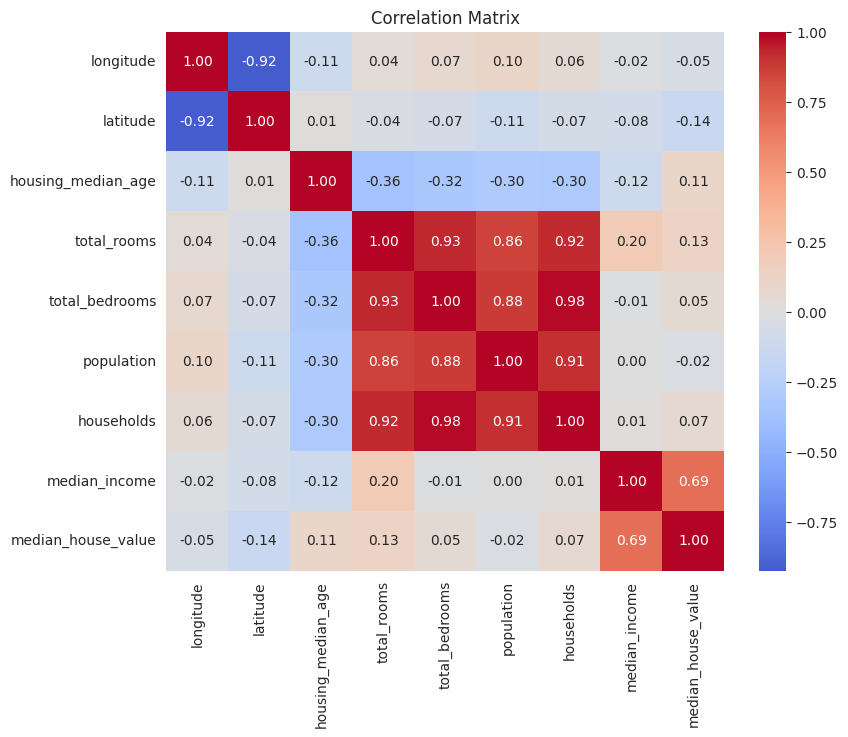

Correlation with median_house_value, sorted:
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


In [9]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

print("Correlation with median_house_value, sorted:")
print(corr_matrix["median_house_value"].sort_values(ascending=False))

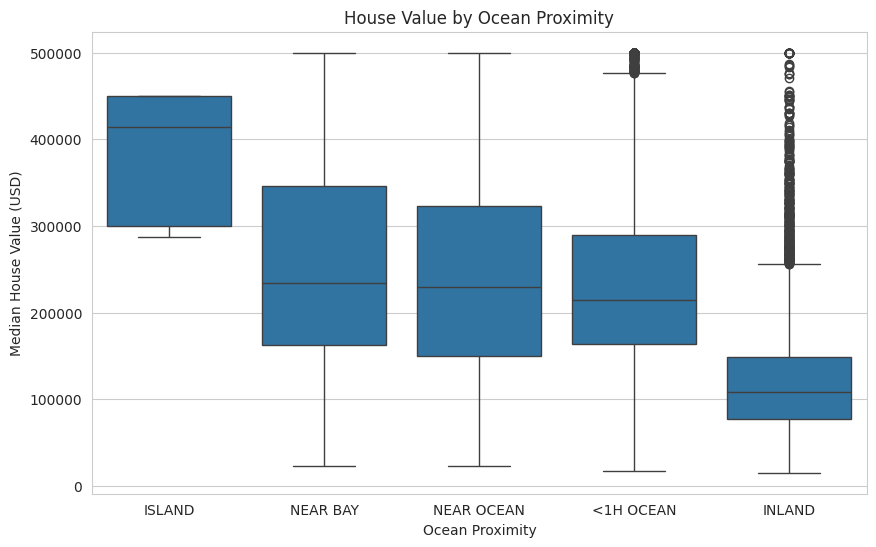

In [10]:
plt.figure(figsize=(10, 6))
order = df.groupby("ocean_proximity")["median_house_value"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value", order=order)
plt.title("House Value by Ocean Proximity")
plt.xlabel("Ocean Proximity")
plt.ylabel("Median House Value (USD)")
plt.show()

### EDA Findings

1. **Income is the strongest single predictor.** `median_income` has by far the highest correlation with `median_house_value` (~0.69) — wealthier neighborhoods have pricier homes, unsurprisingly.
2. **Location matters a lot, and non-linearly.** The map view shows clear coastal price premiums that a simple linear correlation with latitude/longitude alone won't capture well — this is a good candidate for a non-linear model (e.g., Random Forest) or engineered location features.
3. **`ISLAND` and `NEAR BAY`/`NEAR OCEAN`/`<1H OCEAN` command higher median prices than `INLAND`**, confirming that ocean proximity is a meaningful categorical signal (though `ISLAND` has only 5 rows, so its median is unstable).
4. **The target is capped.** There's a visible spike at the top of the `median_house_value` histogram (~\$500,001), meaning very expensive homes were clipped to a ceiling in the original 1990 census data — this will make the model systematically underpredict the priciest neighborhoods.
5. **Room/household counts alone aren't very informative** (`total_rooms`, `total_bedrooms`, `population`, `households` all correlate weakly with price on their own) — but their *ratios* (rooms per household, etc.) are likely to be far more predictive, which we engineer in the next phase.

## 3. Data Cleaning & Preprocessing

In [11]:
print("Missing total_bedrooms:", df["total_bedrooms"].isnull().sum())
print("As % of dataset:", round(df["total_bedrooms"].isnull().mean() * 100, 2), "%")

Missing total_bedrooms: 207
As % of dataset: 1.0 %


**Handling missing `total_bedrooms`:** Only about 1% of rows are missing this value, and there's no indication it's missing for a systematic reason (e.g., tied to one region or house-age bracket) rather than random data-entry gaps. Dropping ~207 rows would lose usable data for little benefit, so we **fill with the median** — it's robust to the outliers/skew visible in the histogram above, unlike the mean.

In [12]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())
print("Missing values remaining:", df["total_bedrooms"].isnull().sum())

Missing values remaining: 0


**Encoding `ocean_proximity`:** One-hot encoding turns the 5 categories into binary columns, which works well since there's no natural ordering between them (e.g., `INLAND` isn't 'more' or 'less' than `NEAR BAY`).

In [13]:
df_encoded = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)
df_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,False,False,True,False
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,False,False,True,False
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,False,False,True,False
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,False,False,True,False
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,False,False,True,False


**Feature engineering:** Raw counts like `total_rooms` or `total_bedrooms` are hard to compare across block groups of different sizes. Turning them into per-household ratios makes them far more meaningful — a block group with 3,000 rooms could be a dense apartment complex or a sprawling suburb depending on how many households live there.

In [14]:
df_encoded["rooms_per_household"] = df_encoded["total_rooms"] / df_encoded["households"]
df_encoded["bedrooms_per_room"] = df_encoded["total_bedrooms"] / df_encoded["total_rooms"]
df_encoded["population_per_household"] = df_encoded["population"] / df_encoded["households"]

df_encoded[["rooms_per_household", "bedrooms_per_room", "population_per_household"]].describe()

,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20640.000000,20640.000000
mean,5.429000,0.213794,3.070655
std,2.474173,0.065248,10.386050
min,0.846154,0.037151,0.692308
25%,4.440716,0.175225,2.429741
50%,5.229129,0.203159,2.818116
75%,6.052381,0.240126,3.282261
max,141.909091,2.824675,1243.333333


In [15]:
X = df_encoded.drop(columns=["median_house_value"])
y = df_encoded["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (16512, 15)
Test shape: (4128, 15)


**Scaling:** Linear Regression benefits from features being on comparable scales (income is ~0-15, but `total_rooms` can be in the thousands). We fit the scaler on the training set only, then apply it to both sets, to avoid leaking test-set information into training.

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Model Training

We train two models and compare them:
- **Linear Regression** — simple, interpretable baseline.
- **Random Forest Regressor** — an ensemble of decision trees that can capture non-linear relationships (like the coastal price effect we saw in the EDA).

In [17]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
print("Linear Regression trained.")

Linear Regression trained.


In [18]:
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)  # tree-based models don't need scaled features
print("Random Forest trained.")

Random Forest trained.


## 5. Evaluation

Since this is regression, we use **MAE**, **RMSE**, and **R²** — not accuracy or a confusion matrix, which only apply to classification.

In [19]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"MAE:  ${mae:,.0f}")
    print(f"RMSE: ${rmse:,.0f}")
    print(f"R2:   {r2:.4f}")
    print()
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

lin_preds = lin_reg.predict(X_test_scaled)
rf_preds = rf_reg.predict(X_test)

results = []
results.append(evaluate("Linear Regression", y_test, lin_preds))
results.append(evaluate("Random Forest", y_test, rf_preds))

results_df = pd.DataFrame(results).set_index("model")
results_df

--- Linear Regression ---
MAE:  $50,889
RMSE: $72,669
R2:   0.5970

--- Random Forest ---
MAE:  $32,139
RMSE: $50,078
R2:   0.8086



,MAE,RMSE,R2
model,,,
Linear Regression,50888.660016,72668.538379,0.597018
Random Forest,32138.504509,50077.729286,0.808626


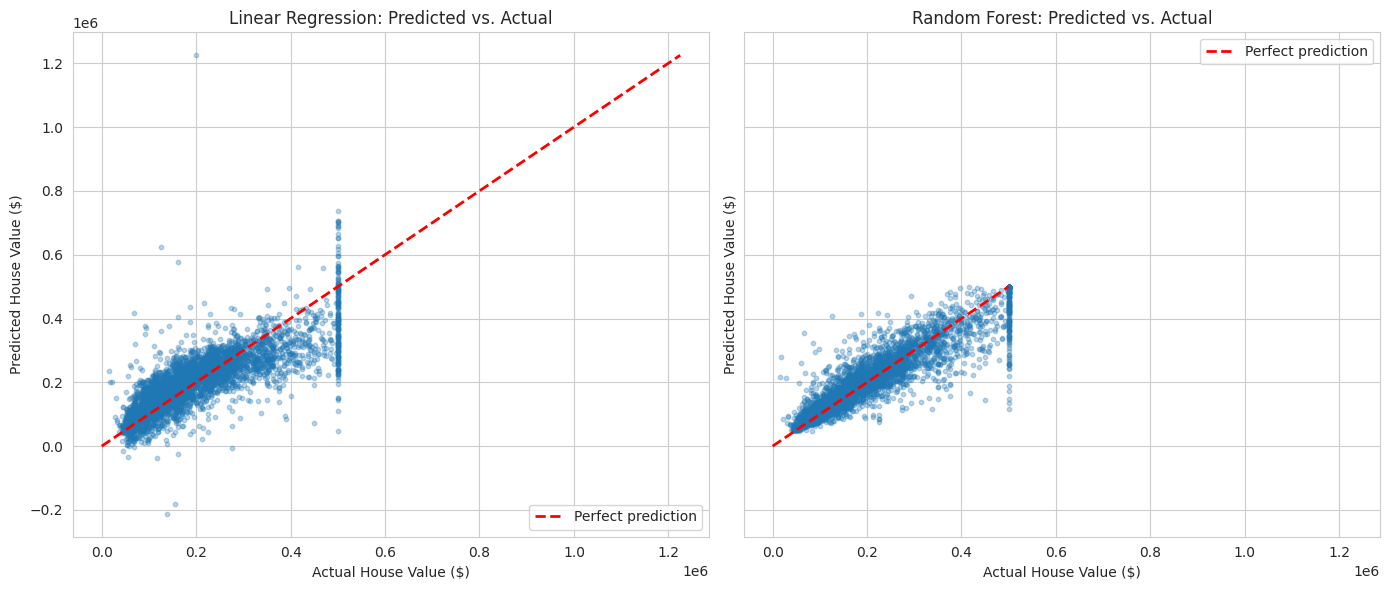

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, preds, name in zip(axes, [lin_preds, rf_preds], ["Linear Regression", "Random Forest"]):
    ax.scatter(y_test, preds, alpha=0.3, s=10)
    lims = [0, max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")
    ax.set_xlabel("Actual House Value ($)")
    ax.set_ylabel("Predicted House Value ($)")
    ax.set_title(f"{name}: Predicted vs. Actual")
    ax.legend()

plt.tight_layout()
plt.show()

The Random Forest's points hug the diagonal noticeably more tightly than Linear Regression's, especially in the mid-price range, confirming it captures the non-linear location/income effects better. Both models show a horizontal band of overpredictions around the \$500,001 cap, where real values were clipped but predictions weren't — this is the capped-target issue flagged in the EDA.

In [21]:
best_model_name = results_df["R2"].idxmax()
print(f"Best model by R2: {best_model_name}")
results_df.sort_values("R2", ascending=False)

Best model by R2: Random Forest


,MAE,RMSE,R2
model,,,
Random Forest,32138.504509,50077.729286,0.808626
Linear Regression,50888.660016,72668.538379,0.597018


## 6. Prediction Demo

A small demo: enter feature values for a hypothetical block group and get a predicted median house value from the best-performing model (Random Forest).

In [22]:
def predict_house_value(longitude, latitude, housing_median_age, total_rooms,
                         total_bedrooms, population, households, median_income,
                         ocean_proximity):
    """Predict median house value for a hypothetical California block group.

    ocean_proximity must be one of: '<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'
    """
    sample = pd.DataFrame([{
        "longitude": longitude,
        "latitude": latitude,
        "housing_median_age": housing_median_age,
        "total_rooms": total_rooms,
        "total_bedrooms": total_bedrooms,
        "population": population,
        "households": households,
        "median_income": median_income,
        "ocean_proximity": ocean_proximity,
    }])

    sample = pd.get_dummies(sample, columns=["ocean_proximity"])
    for col in X.columns:
        if col not in sample.columns:
            sample[col] = 0
    sample["rooms_per_household"] = sample["total_rooms"] / sample["households"]
    sample["bedrooms_per_room"] = sample["total_bedrooms"] / sample["total_rooms"]
    sample["population_per_household"] = sample["population"] / sample["households"]
    sample = sample[X.columns]  # match training column order

    prediction = rf_reg.predict(sample)[0]
    print(f"Predicted median house value: ${prediction:,.0f}")
    return prediction

# Example: a mid-income neighborhood near the coast in the Bay Area
_ = predict_house_value(
    longitude=-122.25, latitude=37.85, housing_median_age=30,
    total_rooms=2500, total_bedrooms=500, population=1200,
    households=470, median_income=5.5, ocean_proximity="NEAR BAY"
)

Predicted median house value: $318,792


In [23]:
# Try a second, contrasting example: an inland, lower-income block group
_ = predict_house_value(
    longitude=-119.5, latitude=36.5, housing_median_age=15,
    total_rooms=1800, total_bedrooms=400, population=900,
    households=350, median_income=2.5, ocean_proximity="INLAND"
)

Predicted median house value: $84,694


## 7. Conclusion

**What worked:**
- Median-income and location were, as expected, the strongest predictors of house value.
- The Random Forest clearly outperformed Linear Regression on every metric, since it could capture the non-linear coastal price effect that a straight-line model can't.
- Simple engineered ratios (`rooms_per_household`, `bedrooms_per_room`, `population_per_household`) added meaningful signal beyond the raw counts.

**What didn't work as well:**
- Linear Regression's errors were noticeably larger for high-value coastal neighborhoods — a single linear coefficient can't represent "expensive near the coast, but only in some places."
- Both models struggle near the \$500,001 cap, since the training data itself was clipped there — no amount of modeling can recover information that was truncated at the source.

**What I'd try next with more time:**
- Try gradient boosting (e.g., XGBoost/LightGBM) or hyperparameter-tune the Random Forest (grid/random search on `n_estimators`, `max_depth`, `min_samples_leaf`).
- Engineer a distance-to-coast or distance-to-major-city feature instead of relying on raw latitude/longitude.
- Investigate or exclude the capped top-value rows separately, since they're not "predictable" in the normal sense.
- Add cross-validation instead of a single train/test split for a more robust performance estimate.